<a href="https://colab.research.google.com/github/anishchapagain/Deep-Learning/blob/main/simple_linear_regression_numpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression with Gradient Descent

Demonstrating the implementation of linear regression using the gradient descent algorithm.

The process involves:
1. **Generating synthetic data**: Creating a dataset that follows a linear relationship with some added noise.
2. **Defining the Mean Squared Error (MSE) cost function**: A function to quantify the difference between the predicted and actual values.
3. **Implementing the gradient descent algorithm**: An iterative optimization algorithm to find the optimal weight (w) and bias (b) that minimize the MSE.
4. **Visualizing the generated data**: Plotting the data to understand its distribution.
5. **Training the model**: Running the gradient descent to learn the optimal parameters.
6. **Evaluating the model**: Checking the final MSE and the learned parameters.

In [3]:
import numpy as np # using mumpy

## Observing data with plot

In [26]:
data = []
w = 2.09
b = 0.9

In [20]:
for i in range(100): # 100 iterations
  x = np.random.uniform(-10,10) # sample x
  y = w*x+b
  data.append([x,y]) # collect x and y value with defined w and b.

In [14]:
data[:10]

[[1.099001441667415, 3.196913013084897],
 [-1.5941929425883377, -2.4318632500096258],
 [-7.0598361538655325, -13.855057561578962],
 [7.572761113001032, 16.727070726172155],
 [-1.9143086240444802, -3.1009050242529637],
 [-5.949625754269792, -11.534717826423863],
 [-3.4384781390279917, -6.286419310568502],
 [-5.3579599355477185, -10.298136265294731],
 [-9.668003028917925, -19.306126330438463],
 [1.2604758775012659, 3.5343945839776456]]

In [15]:
len(data), data[10], data[89]

(100,
 [-7.2402264766665265, -14.23207333623304],
 [-0.21326529997412358, 0.45427552305408175])

In [16]:
import matplotlib.pyplot as plt

In [17]:
# Convert to NumPy array
data_array = np.array(data)

In [18]:
data_array.shape

(100, 2)

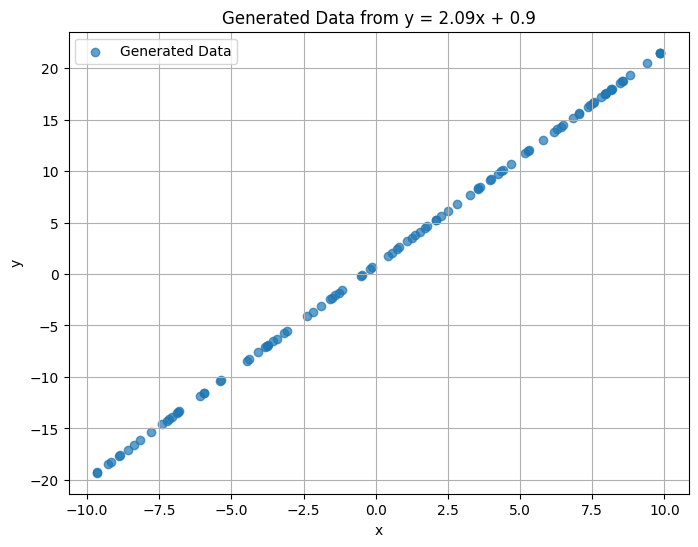

In [19]:
# Plot the data
plt.figure(figsize=(8, 6))
plt.scatter(data_array[:, 0], data_array[:, 1], label='Generated Data', alpha=0.7)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Generated Data from y = 2.09x + 0.9')
plt.legend()
plt.grid(True)
plt.show()

## Progressign with gradient descent and MSE

In [30]:
# Calculate MSE (mean standard error) on current w and b
def calculate_mse(w, b, inputs):
  totalError = 0
  for i in range(0, len(inputs)):
    x = inputs[i, 0]
    y = inputs[i, 1]
    totalError += (y - (w * x + b)) ** 2 # Actual y minus calculated y
  return totalError / float(len(inputs))


In [27]:
def step_gradient(b_current, w_current, inputs, learningRate):
  b_gradient = 0
  w_gradient = 0
  total_sample = len(inputs)
  for i in range(total_sample):
    x = inputs[i, 0]
    y = inputs[i, 1]

    # Calculate the partial derivative of the MSE with respect to b
    # This is derived from the formula: -2/N * sum(y - (wx + b))
    b_gradient += -(2/total_sample) * (y - ((w_current * x) + b_current))

    # Calculate the partial derivative of the MSE with respect to w
    # This is derived from the formula: -2/N * sum(x * (y - (wx + b)))
    w_gradient += -(2/total_sample) * x * (y - ((w_current * x) + b_current))

  # Update b and w using the learning rate and the calculated gradients
  new_b = b_current - (learningRate * b_gradient)
  new_w = w_current - (learningRate * w_gradient)
  return [new_b, new_w]

The `b_gradient` and `w_gradient` in the `step_gradient` function are calculated using the partial derivatives of the Mean Squared Error (MSE) cost function with respect to `b` and `w`, respectively. This is the core idea behind gradient descent.

The MSE cost function is defined as:

$MSE = \frac{1}{N} \sum_{i=1}^{N} (y_i - (wx_i + b))^2$

where:
- $N$ is the total number of samples
- $y_i$ is the actual value of the output for the $i$-th sample
- $x_i$ is the input value for the $i$-th sample
- $w$ is the weight
- $b$ is the bias

To find the gradients, we take the partial derivative of the MSE with respect to $b$ and $w$:

Partial derivative with respect to $b$:

$\frac{\partial MSE}{\partial b} = \frac{\partial}{\partial b} \left( \frac{1}{N} \sum_{i=1}^{N} (y_i - (wx_i + b))^2 \right)$
$= \frac{1}{N} \sum_{i=1}^{N} \frac{\partial}{\partial b} (y_i - wx_i - b)^2$

Using the chain rule,
$\frac{\partial}{\partial b} (y_i - wx_i - b)^2 = 2(y_i - wx_i - b) \cdot \frac{\partial}{\partial b} (y_i - wx_i - b) = 2(y_i - wx_i - b) \cdot (-1) = -2(y_i - wx_i - b)$

So,
$\frac{\partial MSE}{\partial b} = \frac{1}{N} \sum_{i=1}^{N} -2(y_i - (wx_i + b)) = -\frac{2}{N} \sum_{i=1}^{N} (y_i - (wx_i + b))$

This is the formula used to calculate `b_gradient`.
<hr/>
Partial derivative with respect to $w$:
$\frac{\partial MSE}{\partial w} = \frac{\partial}{\partial w} \left( \frac{1}{N} \sum_{i=1}^{N} (y_i - (wx_i + b))^2 \right)$
$= \frac{1}{N} \sum_{i=1}^{N} \frac{\partial}{\partial w} (y_i - wx_i - b)^2$

Using the chain rule,
$\frac{\partial}{\partial w} (y_i - wx_i - b)^2 = 2(y_i - wx_i - b) \cdot \frac{\partial}{\partial w} (y_i - wx_i - b) = 2(y_i - wx_i - b) \cdot (-x_i) = -2x_i(y_i - wx_i - b)$
So, $\frac{\partial MSE}{\partial w} = \frac{1}{N} \sum_{i=1}^{N} -2x_i(y_i - (wx_i + b)) = -\frac{2}{N} \sum_{i=1}^{N} x_i(y_i - (wx_i + b))$

This is the formula used to calculate `w_gradient`.
<hr/>
These gradients indicate the direction of the steepest increase in the MSE. In gradient descent, we want to move in the opposite direction (down the slope) to minimize the error, hence the subtraction of `learningRate * gradient` from the current `b` and `w` values.

In [21]:
def gradient_descent(inputs, start_b, start_w, learning_rate, num_iterations):
  # updating w and b
  b = start_b # starting value of b
  w = start_w # starting value of w

  for step in range(num_iterations):
    # Update w, b
    b, w = step_gradient(b, w, inputs, learning_rate)

    # Calculate the current MSE
    mse = calculate_mse(w, b, inputs)
    if step%20==0:
      print(f"Iteration {step}: MSE = {mse}, b = {b}, w = {w}")
  return [b, w]


In [28]:
def main(w, b):
  data = []
  for i in range(100): # 100 iterations
    x = np.random.uniform(-10,10) # sample x
    y = w*x+b
    data.append([x,y])

  data = np.array(data)
  lr = 0.01
  initial_b = 0 # initial value of b
  initial_w = 0 # initial value of w
  num_iterations = 100

  [b, w] = gradient_descent(data, initial_b, initial_w, lr, num_iterations)
  loss = calculate_mse(w, b, data)
  print(f"Final loss: {loss}, w: {w}, b: {b}")

In [32]:
print(f"Initial Weight: {w} Bias {b}")
main(w, b)

Initial Weight: 2.09 Bias 0.9
Iteration 0: MSE = 21.218494912620887, b = -0.009384266088550666, w = 1.2471527066561972
Iteration 20: MSE = 0.3828352444011242, b = 0.27681211168651504, w = 2.0759861206397385
Iteration 40: MSE = 0.17269392529031624, b = 0.4814459212087797, w = 2.0805878096090824
Iteration 60: MSE = 0.0779008523074475, b = 0.6188849139913841, w = 2.0836784543614684
Iteration 80: MSE = 0.035140453145788814, b = 0.7111935934064794, w = 2.08575423598543
Final loss: 0.01649526315471085, w: 2.0870910798685482, b: 0.7706421847275898
